# Analiza Supraviețuirii pe Titanic
## 1. Importarea bibliotecilor și încărcarea datelor
În această primă secțiune, vom importa bibliotecile esențiale pentru manipularea datelor (`pandas`) și pentru crearea vizualizărilor (`seaborn` și `matplotlib`). De asemenea, setăm o temă vizuală globală pentru grafice și încărcăm faimosul set de date "Titanic" direct din librăria Seaborn.

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', palette='muted')
titanic = sns.load_dataset('titanic')

## 2. Explorarea inițială a setului de date
Înainte de a face analize complexe, trebuie să înțelegem cu ce date lucrăm. Aici verificăm dimensiunea tabelului (numărul de rânduri și coloane), identificăm ce coloane au date lipsă (cum ar fi vârsta sau puntea) și calculăm rata globală de supraviețuire pentru a avea un punct de referință (baseline).

In [13]:
print("=== Informații generale ===")
print(f"Dimensiune: {titanic.shape}")
print(f"\nValori lipsă:\n{titanic.isnull().sum()[titanic.isnull().sum() > 0]}")
print(f"\nRata globală de supraviețuire: {titanic['survived'].mean():.1%}")

=== Informații generale ===
Dimensiune: (891, 15)

Valori lipsă:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

Rata globală de supraviețuire: 38.4%


## 3. Analiza ratei de supraviețuire per Sex și Clasă
Pentru a descoperi tiparele de supraviețuire, vom grupa datele. Mai întâi, calculăm rata de supraviețuire strict în funcție de sex. Apoi, facem același lucru în funcție de clasa biletului (First, Second, Third), folosind funcția `groupby` din Pandas.

In [14]:
print("\n=== Rata de supraviețuire per sex ===")
rata_sex = titanic.groupby('sex', observed=True)['survived'].mean().round(3)
print(rata_sex)

print("\n=== Rata de supraviețuire per clasă ===")
rata_clasa = titanic.groupby('class', observed=True)['survived'].mean().round(3)
print(rata_clasa)


=== Rata de supraviețuire per sex ===
sex
female    0.742
male      0.189
Name: survived, dtype: float64

=== Rata de supraviețuire per clasă ===
class
First     0.630
Second    0.473
Third     0.242
Name: survived, dtype: float64


## 4. Analiză încrucișată: Sex și Clasă simultan
Pentru o perspectivă mai profundă, folosim un tabel pivot (`pivot_table`). Acesta ne permite să combinăm ambele variabile (Sex și Clasă) pentru a vedea rata de supraviețuire a fiecărui subgrup în parte (ex: femei din clasa I vs. bărbați din clasa a III-a).

In [15]:
print("\n=== Rata de supraviețuire per sex și clasă ===")
pivot = titanic.pivot_table(
    values='survived',
    index='class',
    columns='sex',
    aggfunc='mean',
    observed=True
).round(3)
print(pivot)


=== Rata de supraviețuire per sex și clasă ===
sex     female   male
class                
First    0.968  0.369
Second   0.921  0.157
Third    0.500  0.135


## 5. Vizualizarea Datelor (Dashboard)
Numerele sunt utile, dar graficele spun povestea mult mai clar. În această secțiune, construim un panou de control (dashboard) format din 3 grafice cu bare (subplots). Primul grafic arată diferența de supraviețuire între sexe, al doilea între clasele sociale, iar al treilea le combină. La final, salvăm acest dashboard la o rezoluție înaltă, gata pentru a fi inclus într-un raport.

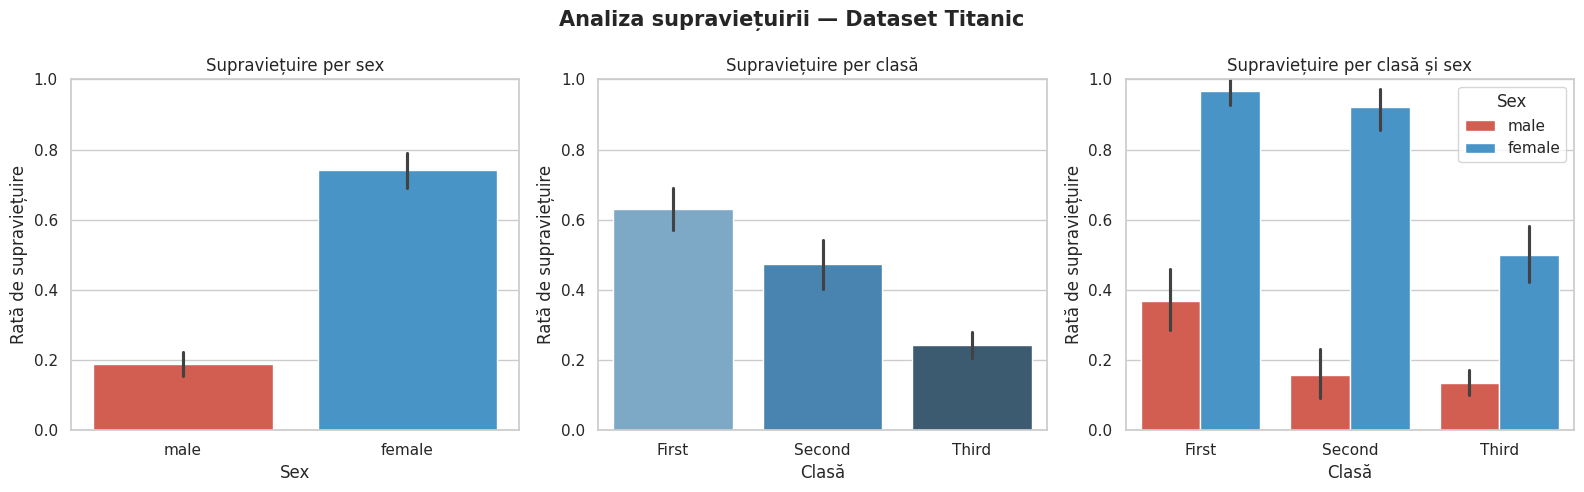

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Analiza supraviețuirii — Dataset Titanic', fontsize=15, fontweight='bold')

# Subplot 1: Rata de supraviețuire per sex
sns.barplot(data=titanic, x='sex', y='survived', hue='sex', ax=axes[0],
            errorbar='ci', palette=['#e74c3c', '#3498db'], legend=False)
axes[0].set_title('Supraviețuire per sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Rată de supraviețuire')
axes[0].set_ylim(0, 1)

# Subplot 2: Rata de supraviețuire per clasă
sns.barplot(data=titanic, x='class', y='survived', hue='class', ax=axes[1],
            errorbar='ci', order=['First', 'Second', 'Third'],
            palette='Blues_d', legend=False)
axes[1].set_title('Supraviețuire per clasă')
axes[1].set_xlabel('Clasă')
axes[1].set_ylabel('Rată de supraviețuire')
axes[1].set_ylim(0, 1)

# Subplot 3: Rata per sex și clasă
sns.barplot(data=titanic, x='class', y='survived', hue='sex',
            ax=axes[2], errorbar='ci',
            order=['First', 'Second', 'Third'],
            palette=['#e74c3c', '#3498db'])
axes[2].set_title('Supraviețuire per clasă și sex')
axes[2].set_xlabel('Clasă')
axes[2].set_ylabel('Rată de supraviețuire')
axes[2].set_ylim(0, 1)
axes[2].legend(title='Sex')

plt.tight_layout()
plt.savefig('titanic_analiza.png', dpi=150, bbox_inches='tight')
plt.show()

## Concluzii asupra analizei datelor
În urma analizei exploratorii, datele confirmă aplicarea strictă a protocolului maritim "femeile și copiii primii", femeile având o rată de supraviețuire disproporționat mai mare comparativ cu bărbații. De asemenea, se observă o corelație puternică între statutul socio-economic și șansele de supraviețuire, pasagerii din Clasa I având un avantaj semnificativ față de cei din Clasele a II-a și a III-a. Această disparitate atinge punctul maxim atunci când combinăm factorii: femeile din Clasa I au supraviețuit aproape în totalitate, în timp ce bărbații din Clasa a III-a au înregistrat cele mai tragice pierderi, subliniind impactul combinat al normelor sociale și al privilegiului financiar.